In [5]:
import os
import sys
from os.path import join
import copy

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)
    
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import corner
import torch
from torch.utils.data import DataLoader, Subset
import pyxis.torch as pxt

from networks import *
from train import (
    load_model,
    apply_noise,
)
import config
from utils import (
    denormalize,
    make_corner_plot,
)
from data import rotate_90_degrees

stem = 'CNN-CNN-flow_small_baseline'
data_dir = '/ocean/projects/phy250048p/shared/datasets/valid_1m'
samp_dir = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'
fig_dir = '/ocean/projects/phy250048p/shared/figures/'
model_dir = f'/ocean/projects/phy250048p/shared/models/{stem}/'
loss_dir = '/ocean/projects/phy250048p/shared/models/losses/'
results_dir = '/ocean/projects/phy250048p/shared/results/'
cache_dir = '/ocean/projects/phy250048p/shared/cache/'

In [2]:
plt.rcParams.update({"text.usetex": False, "font.family": "serif", "figure.dpi": 300})
os.makedirs(join(fig_dir, stem), exist_ok=True)

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
model_file = join(model_dir, f'{stem}199')
model = load_model(mode=1, path=model_file,strict=True, assign=True, device=device)

In [3]:
# Get data loader
bs = 1
test_args = list(config.test.values())
test_ds = pxt.TorchDataset(data_dir)
test_dl = DataLoader(test_ds,
                     batch_size=bs,
                     pin_memory=False,
                     shuffle=False,)
nsub = 1
subset = Subset(test_ds, np.arange(0, nsub))
sub_dl = DataLoader(subset,
                    batch_size=bs,
                    pin_memory=False,
                    shuffle=False,)

In [6]:
samples = pd.read_csv(samp_dir)

In [15]:
whr = np.where(samples['sini'] > 0.8)[0]

In [17]:
img = test_ds[whr[0]]['img'].unsqueeze(0).to(device)
fid = test_ds[whr[0]]['fid_pars'].unsqueeze(0).to(device)
fp = test_ds[whr[0]]['fib_pos'].unsqueeze(0).to(device)

In [19]:
img_90, fid_90, fp_90 = rotate_90_degrees(img, fid=fid, fp=fp)

In [23]:
print(fp, fp_90)

tensor([[[-0.9904,  1.1265],
         [ 0.9904, -1.1265],
         [ 0.0000,  0.0000],
         [ 1.1265,  0.9904],
         [-1.1265, -0.9904]]], dtype=torch.float64) tensor([[[-1.1265, -0.9904],
         [ 1.1265,  0.9904],
         [ 0.0000,  0.0000],
         [-0.9904,  1.1265],
         [ 0.9904, -1.1265]]], dtype=torch.float64)


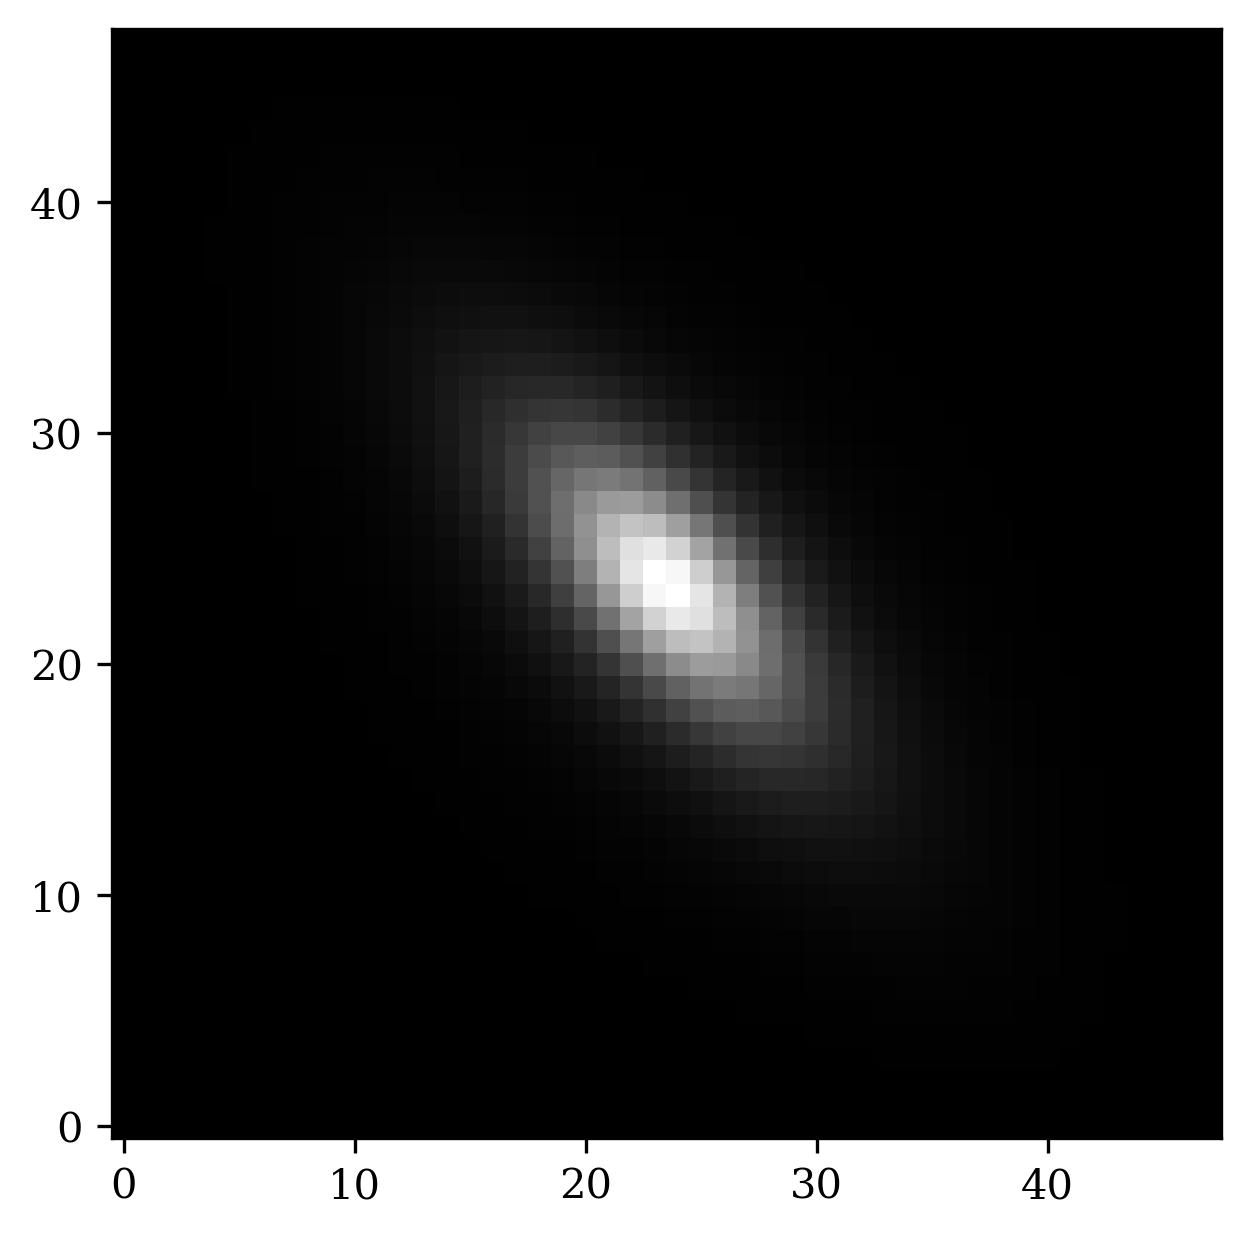

In [ ]:
plt.imshow(img_90[0, 0].cpu(), origin='lower', cmap='gray')
plt.show()

In [8]:
model.bs = 1

In [11]:
model.eval()
trues = []
latents = []
# rmag = sample_magnitudes(nsub, m_min=15, m_max=23)
# a, b = _load_rmag_snr_relation()
# log_snr = (rmag - b) / a
# snrs = torch.from_numpy(10**log_snr).float().to(device)
snrs = torch.rand((10000,), device=device)*995 + 5
with torch.no_grad():
    for i, batch in enumerate(sub_dl):
        for j in range(10000):
            # snr = snrs[i*bs:(i+1)*bs]
            snr = snrs[j]
            img = apply_noise(batch['img'].float().to(device), snr, device=device)
            spec = apply_noise(batch['spec'].float().to(device), snr, device=device)
            fid = batch['fid_pars'].float().to(device)
            fp = apply_noise(batch['fib_pos'].unsqueeze(0).float().to(device), snr, device=device)[0]
            latent = model.extract_latent(img, spec, fid, fp=fp)
            latents.append(latent.detach().cpu().numpy())
            trues.append(fid.cpu().numpy())
trues = np.vstack(trues)
latents = np.vstack(latents)
snrs = snrs.cpu().numpy()

In [13]:
print(trues[0])

[-0.49859086 -0.617203   -0.42577192 -0.81995    -0.73902124  0.17281759
  0.572954    0.29849952]


In [7]:
latents.shape

(100000, 8)

Removed no burn in


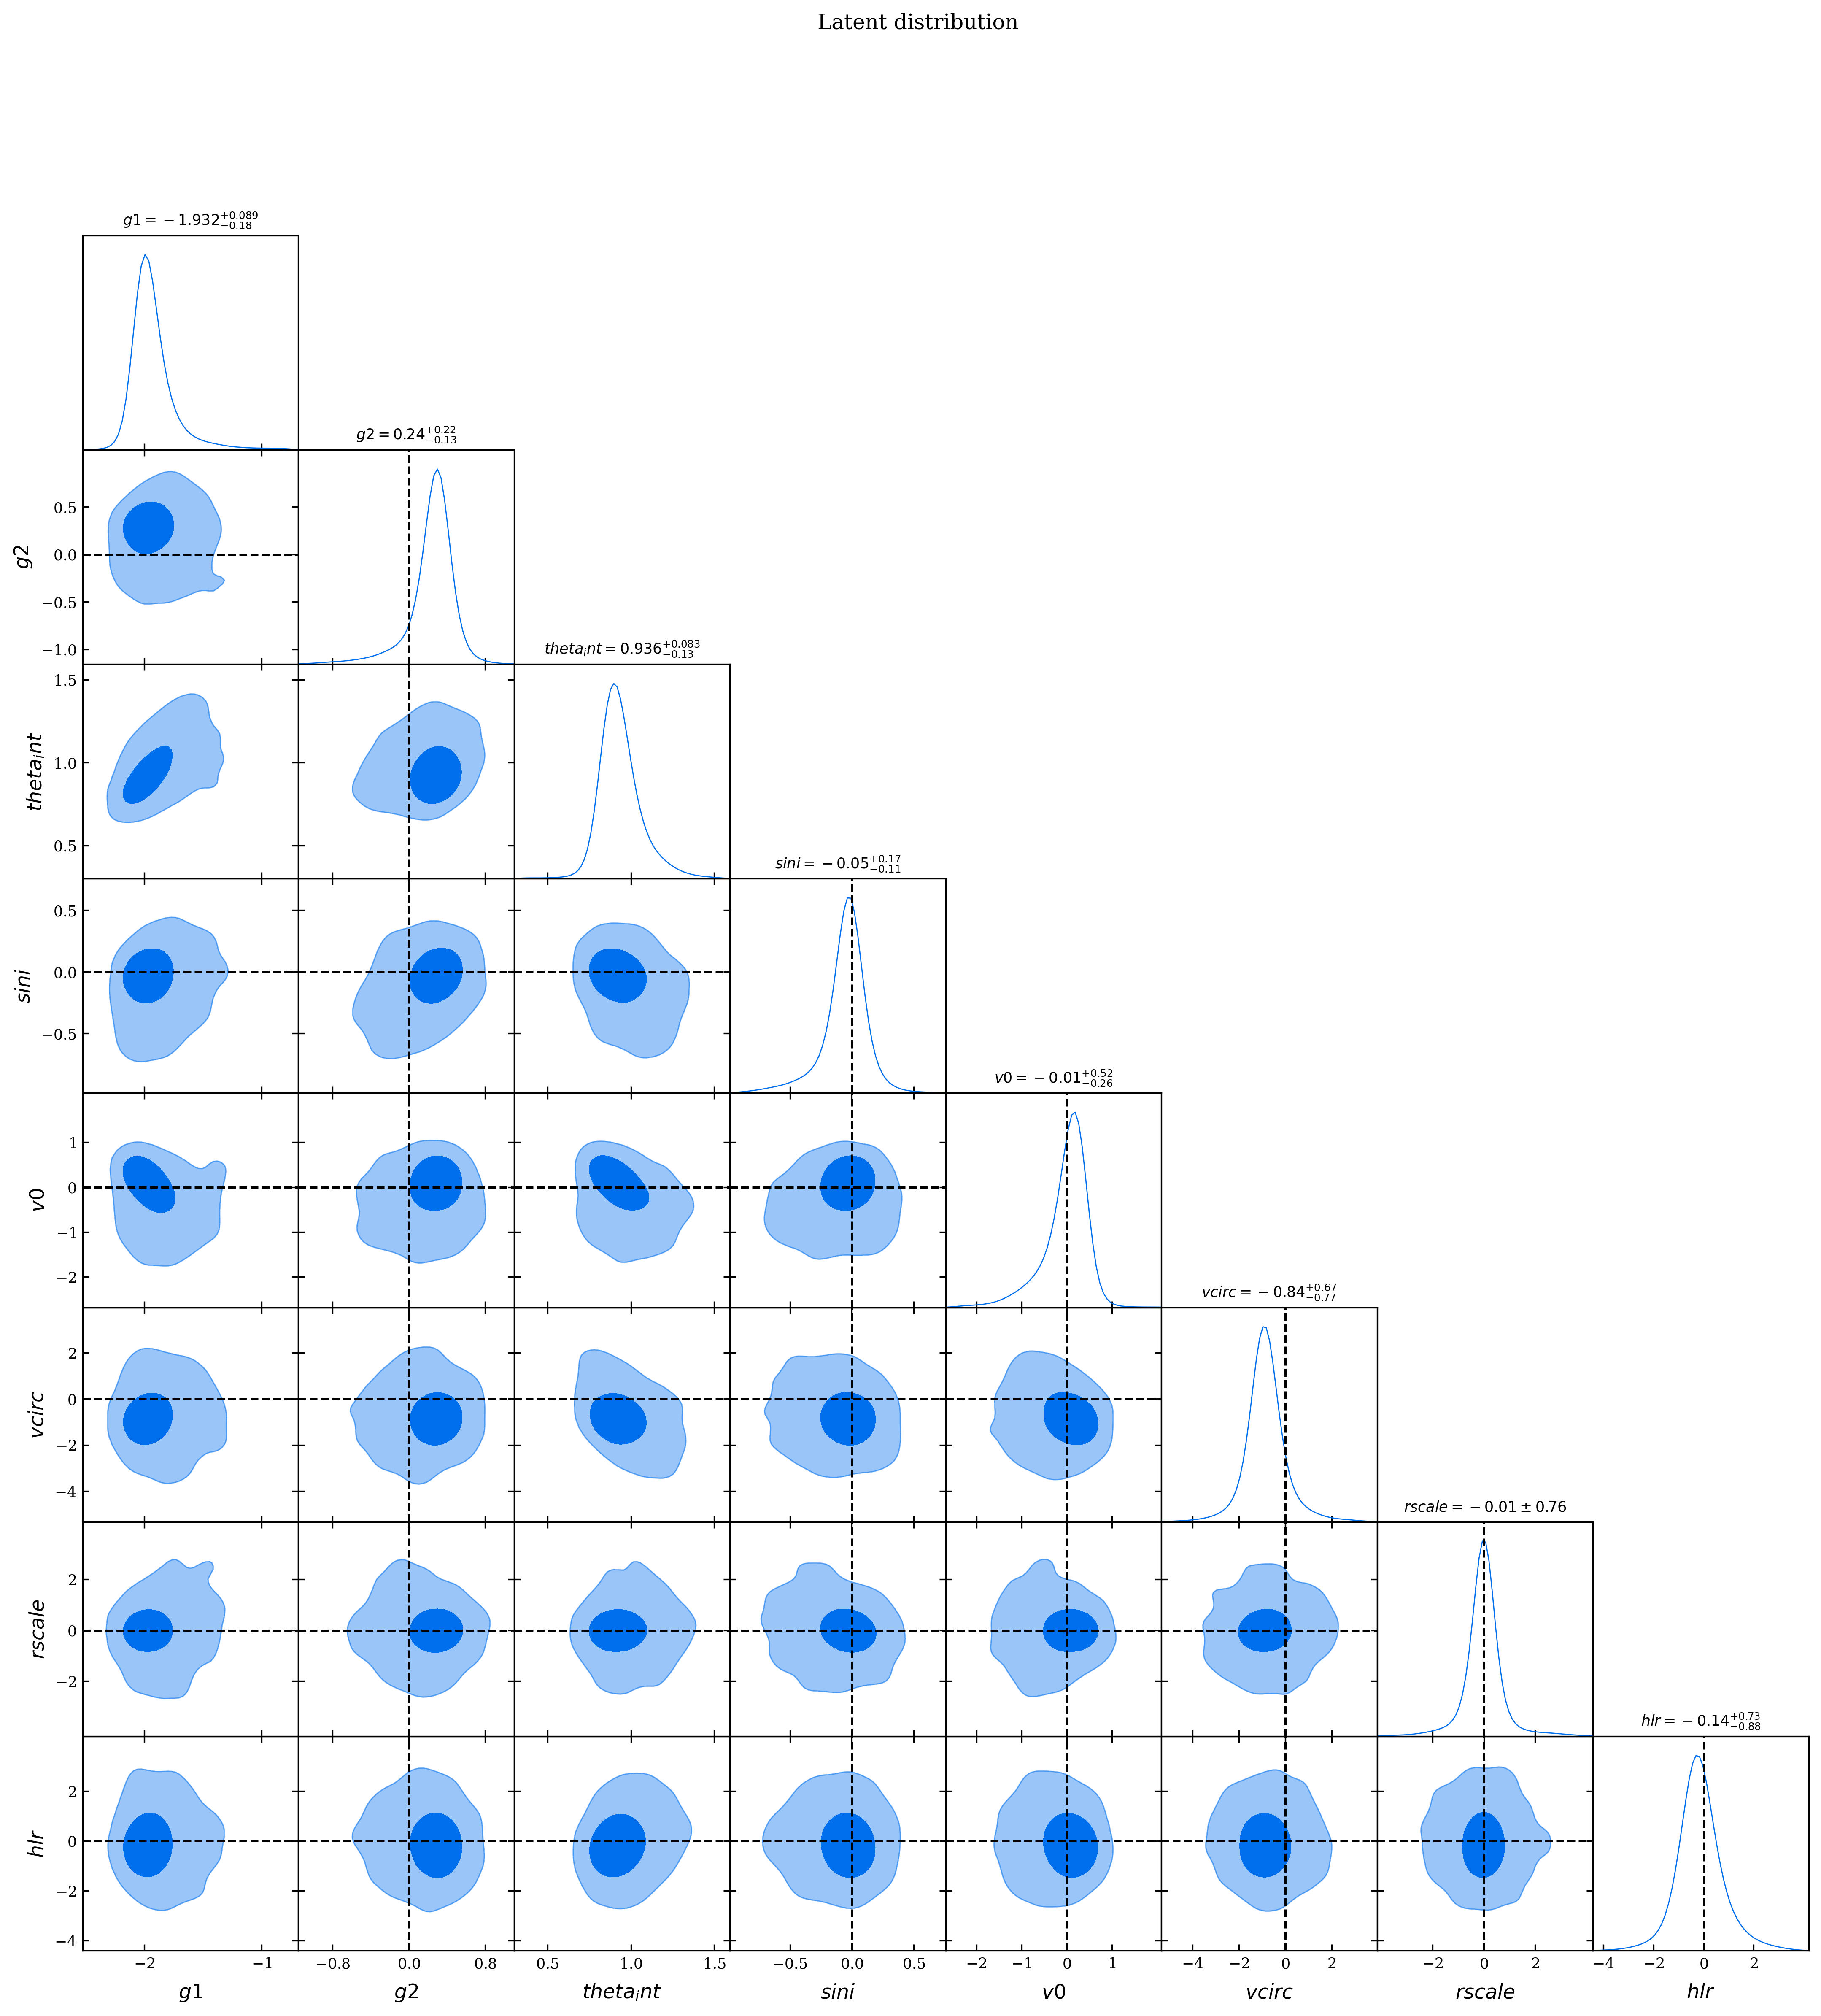

In [12]:
fig, _, _ = make_corner_plot(
    latents,
    truth=np.zeros((8)),
    labels=config.train['feature_names'],
    suptitle=f'Latent distribution',
)
# fig.savefig(join(fig_dir, stem, f'latent_distribution.png'), dpi=300)